# Figure 4: Motivated reasoning by topic

This notebook reproduces Stata Figure 4 using pandas, scikit-learn, and matplotlib.

The figure plots coefficients from a regression of `prob_true` on `good_topic*` indicators (pro-party news × topic interactions), with fixed effects for round, topic, and code cluster variable.

Topics are sorted by coefficient magnitude, displayed with 95% confidence intervals.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Imports successful")

Imports successful


In [13]:
# Load data
data_path = '../data/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"Data loaded: shape {df.shape}")
print(f"Columns: {df.columns.tolist()[:20]}...")

Data loaded: shape (13818, 331)
Columns: ['id_in_session', 'code', 'index_in_pages', 'current_page_name', 'time_started', 'payoff', 'consent', 'treatment', 'age_temp', 'gender', 'race_ethnicity', 'religion', 'region', 'party', 'ideology_temp', 'rep_thermometer', 'dem_thermometer', 'quiz1', 'quiz2', 'quiz3']...


In [14]:
# Filter to appropriate sample: net_party != 0
sub = df[df['net_party'] != 0].copy()

print(f"After filtering net_party != 0: {len(sub)} rows")
print(f"Unique codes (clusters): {sub['code'].nunique()}")

After filtering net_party != 0: 12558 rows
Unique codes (clusters): 897


In [15]:
# Identify good_topic columns (these already exist in the data)
good_topic_cols = [col for col in sub.columns if col.startswith('good_topic') and '_demeaned' not in col]
good_topic_cols = sorted(good_topic_cols, key=lambda x: int(x.replace('good_topic', '').replace('1415', '99')) if x != 'good_topic1415' else 99)

print(f"Found {len(good_topic_cols)} good_topic variables:")
print(good_topic_cols)

# Check data types and missing values
print(f"\nData types for first few good_topic cols:")
for col in good_topic_cols[:5]:
    print(f"  {col}: {sub[col].dtype}, missing: {sub[col].isna().sum()}")

Found 16 good_topic variables:
['good_topic1', 'good_topic2', 'good_topic3', 'good_topic4', 'good_topic5', 'good_topic6', 'good_topic7', 'good_topic8', 'good_topic9', 'good_topic10', 'good_topic11', 'good_topic12', 'good_topic13', 'good_topic14', 'good_topic15', 'good_topic1415']

Data types for first few good_topic cols:
  good_topic1: int64, missing: 0
  good_topic2: int64, missing: 0
  good_topic3: int64, missing: 0
  good_topic4: int64, missing: 0
  good_topic5: int64, missing: 0


In [16]:
# Prepare regression data
# Dependent variable: prob_true
# Independent variables: good_topic* indicators
# Fixed effects: round_number, topic_id (will be absorbed via demeaning)
# Cluster variable: code

y = sub['prob_true'].astype(float).values
X = sub[good_topic_cols].astype(float).values

print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")
print(f"Missing in y: {np.isnan(y).sum()}")
print(f"Missing in X: {np.isnan(X).sum()}")

y shape: (12558,)
X shape: (12558, 16)
Missing in y: 75
Missing in X: 0


In [17]:
# Manual fixed effects demeaning
# Demean within each (round_number, topic_id) cell

sub_copy = sub.copy()
sub_copy['y'] = y

# Add X columns temporarily
for i, col in enumerate(good_topic_cols):
    sub_copy[f'X_{i}'] = X[:, i]

# Demean y and X within each FE group
y_demeaned = sub_copy.groupby(['round_number', 'topic_id'])['y'].transform(lambda x: x - x.mean()).values

X_demeaned = X.copy()
for i, col in enumerate(good_topic_cols):
    X_demeaned[:, i] = sub_copy.groupby(['round_number', 'topic_id'])[f'X_{i}'].transform(lambda x: x - x.mean()).values

# Remove rows with NaN (from demeaning)
valid_idx = ~(np.isnan(y_demeaned) | np.isnan(X_demeaned).any(axis=1))
y_demeaned = y_demeaned[valid_idx]
X_demeaned = X_demeaned[valid_idx]

print(f"After demeaning:")
print(f"  y_demeaned shape: {y_demeaned.shape}")
print(f"  X_demeaned shape: {X_demeaned.shape}")

After demeaning:
  y_demeaned shape: (12483,)
  X_demeaned shape: (12483, 16)


In [20]:
# Fit OLS on demeaned data with cluster-robust SE
from sklearn.linear_model import LinearRegression

# Fit model (no intercept since already demeaned)
model = LinearRegression(fit_intercept=False)
model.fit(X_demeaned, y_demeaned)

coef = model.coef_
y_pred = model.predict(X_demeaned)
residuals = y_demeaned - y_pred

print(f"Coefficients: {coef}")
print(f"Residual SS: {np.sum(residuals**2):.4f}")

Coefficients: [1.46495628e-01 9.91358115e-02 8.42268909e-02 6.10842256e-02
 1.08878627e-01 8.00619237e-02 1.05608429e-01 1.06640861e-02
 0.00000000e+00 0.00000000e+00 4.16333634e-17 6.93889390e-18
 6.50765779e-02 3.68741658e-02 4.82951179e-02 8.51692837e-02]
Residual SS: 685.9422


In [28]:
# Compute cluster-robust standard errors
# Get cluster assignment for non-dropped observations
clusters = sub[valid_idx]['code'].values
unique_clusters = np.unique(clusters)
n_clusters = len(unique_clusters)
n = len(y_demeaned)

# Drop zero-variance columns (these cause singular matrix)
col_variances = np.var(X_demeaned, axis=0)
nonzero_var_idx = col_variances > 1e-10
X_demeaned_clean = X_demeaned[:, nonzero_var_idx]
good_topic_cols_clean = [col for i, col in enumerate(good_topic_cols) if nonzero_var_idx[i]]

print(f"Dropped {(~nonzero_var_idx).sum()} zero-variance columns")

# Also drop perfect multicollinear columns using QR decomposition
Q, R = np.linalg.qr(X_demeaned_clean)
# Columns with very small diagonal in R are redundant
rank = np.sum(np.abs(np.diag(R)) > 1e-10)
X_demeaned_clean = X_demeaned_clean[:, :rank]
good_topic_cols_clean = good_topic_cols_clean[:rank]

print(f"After QR rank test, keeping {rank} columns: {good_topic_cols_clean}")

k = X_demeaned_clean.shape[1]

# Refit model on cleaned data
model = LinearRegression(fit_intercept=False)
model.fit(X_demeaned_clean, y_demeaned)
coef = model.coef_
y_pred = model.predict(X_demeaned_clean)
residuals = y_demeaned - y_pred

# Compute X'X inverse
XtX = X_demeaned_clean.T @ X_demeaned_clean
try:
    XtX_inv = np.linalg.inv(XtX)
except np.linalg.LinAlgError:
    print("XtX is still singular, using pseudoinverse")
    XtX_inv = np.linalg.pinv(XtX)

# Compute cluster-robust meat matrix
# For each cluster g: sum_g (X_g' * u_g) * (X_g' * u_g)'
meat = np.zeros((k, k))
for clust in unique_clusters:
    mask = clusters == clust
    X_c = X_demeaned_clean[mask]
    u_c = residuals[mask]
    Xu = X_c.T @ u_c  # (k,)
    meat += np.outer(Xu, Xu)  # (k, k)

# Cluster-robust VC: (n / n_clusters) * (X'X)^{-1} * meat * (X'X)^{-1}
vc_cluster = (n / n_clusters) * XtX_inv @ meat @ XtX_inv
se = np.sqrt(np.diag(vc_cluster))

# Compute 95% CI using t-distribution
df_resid = n - k
t_crit = stats.t.ppf(0.975, df_resid)
ci_lower = coef - t_crit * se
ci_upper = coef + t_crit * se

print(f"\nSample info:")
print(f"  n = {n}, k = {k}, n_clusters = {n_clusters}")
print(f"  df_resid = {df_resid}, t_crit(0.975) = {t_crit:.4f}")
print(f"\nResults (with cluster-robust SE):")
for i, col in enumerate(good_topic_cols_clean):
    print(f"  {col:20s}: coef={coef[i]:7.4f}, se={se[i]:7.4f}, 95% CI=[{ci_lower[i]:7.4f}, {ci_upper[i]:7.4f}]")

Dropped 4 zero-variance columns
After QR rank test, keeping 11 columns: ['good_topic1', 'good_topic2', 'good_topic3', 'good_topic4', 'good_topic5', 'good_topic6', 'good_topic7', 'good_topic8', 'good_topic13', 'good_topic14', 'good_topic15']

Sample info:
  n = 12483, k = 11, n_clusters = 897
  df_resid = 12472, t_crit(0.975) = 1.9602

Results (with cluster-robust SE):
  good_topic1         : coef= 0.1465, se= 0.0732, 95% CI=[ 0.0031,  0.2899]
  good_topic2         : coef= 0.0991, se= 0.0588, 95% CI=[-0.0161,  0.2143]
  good_topic3         : coef= 0.0842, se= 0.0592, 95% CI=[-0.0318,  0.2002]
  good_topic4         : coef= 0.0611, se= 0.0573, 95% CI=[-0.0511,  0.1733]
  good_topic5         : coef= 0.1089, se= 0.0609, 95% CI=[-0.0105,  0.2282]
  good_topic6         : coef= 0.0801, se= 0.0587, 95% CI=[-0.0351,  0.1952]
  good_topic7         : coef= 0.1056, se= 0.0580, 95% CI=[-0.0081,  0.2193]
  good_topic8         : coef= 0.0107, se= 0.0611, 95% CI=[-0.1090,  0.1304]
  good_topic13       

In [29]:
# Create coefplot DataFrame
topic_labels = {
    'good_topic1': 'Pro-Party x Climate',
    'good_topic2': 'Pro-Party x Refugees',
    'good_topic3': 'Pro-Party x Obama crime',
    'good_topic4': 'Pro-Party x Gun laws',
    'good_topic5': 'Pro-Party x Race',
    'good_topic6': 'Pro-Party x Gender',
    'good_topic7': 'Pro-Party x Mobility',
    'good_topic8': 'Pro-Party x Media',
    'good_topic1415': 'Pro-Party x Party score',
    'good_topic13': 'Pro-Performance'
}

coef_df = pd.DataFrame({
    'topic': good_topic_cols_clean,
    'coef': coef,
    'se': se,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper
})

# Add labels
coef_df['label'] = coef_df['topic'].map(topic_labels)
coef_df['label'] = coef_df['label'].fillna(coef_df['topic'])  # Use topic name if no label

# Sort by coefficient value (for coefplot)
coef_df = coef_df.sort_values('coef').reset_index(drop=True)

print(coef_df[['topic', 'label', 'coef', 'ci_lower', 'ci_upper']])

           topic                    label      coef  ci_lower  ci_upper
0    good_topic8        Pro-Party x Media  0.010664 -0.109032  0.130360
1    good_topic4     Pro-Party x Gun laws  0.061084 -0.051138  0.173307
2   good_topic13          Pro-Performance  0.065077 -0.062413  0.192566
3    good_topic6       Pro-Party x Gender  0.080062 -0.035091  0.195215
4    good_topic3  Pro-Party x Obama crime  0.084227 -0.031754  0.200207
5    good_topic2     Pro-Party x Refugees  0.099136 -0.016055  0.214326
6    good_topic7     Pro-Party x Mobility  0.105608 -0.008117  0.219334
7    good_topic5         Pro-Party x Race  0.108879 -0.010478  0.228235
8   good_topic14             good_topic14  0.122043 -0.039891  0.283978
9   good_topic15             good_topic15  0.133464 -0.022577  0.289506
10   good_topic1      Pro-Party x Climate  0.146496  0.003064  0.289927


Figure 4 saved to ../figures/figure4.png


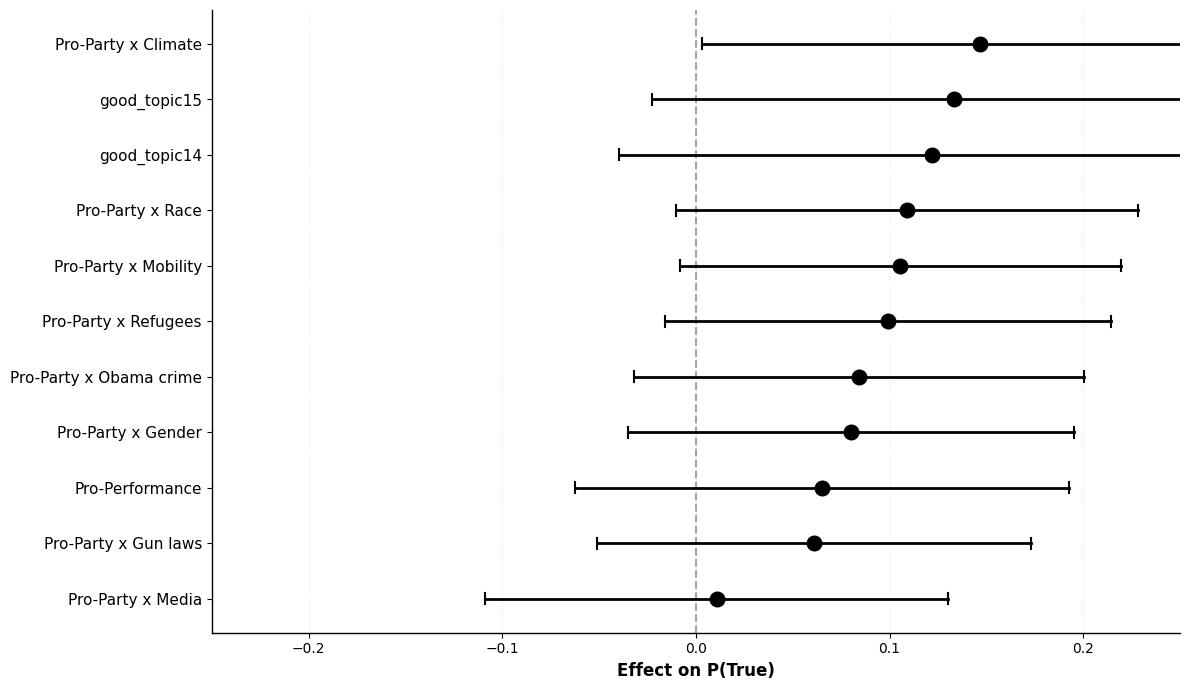

In [30]:
# Create coefplot (horizontal bar plot with CIs)
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(coef_df))

# Plot points (coefficients)
ax.scatter(coef_df['coef'], y_pos, color='black', s=100, zorder=3, edgecolors='black', linewidth=1.5)

# Plot confidence interval lines
for i, row in coef_df.iterrows():
    ax.plot([row['ci_lower'], row['ci_upper']], [i, i], color='black', linewidth=2, zorder=2)
    # Add cap lines
    ax.plot([row['ci_lower'], row['ci_lower']], [i-0.1, i+0.1], color='black', linewidth=1.5)
    ax.plot([row['ci_upper'], row['ci_upper']], [i-0.1, i+0.1], color='black', linewidth=1.5)

# Add vertical line at x=0
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# Set y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df['label'], fontsize=11)

# Set x-axis labels
ax.set_xlabel('Effect on P(True)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.25, 0.25)

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../figures/figure4.png', dpi=300, bbox_inches='tight')
print("Figure 4 saved to ../figures/figure4.png")
plt.show()